## Section 3 – MCP (McCulloch–Pitts) Neurons

The MCP neuron (1943) is the first computational model of a biological neuron. It works as follows:

1. **Sum** all binary inputs: `g(X) = Σ xᵢ`
2. If **any input is inhibitory** → output = 0
3. If `g(X) ≥ T` (threshold) → output = 1, else output = 0

Inputs are binary (0 or 1). Weights are fixed and equal (no learning).

In [1]:
# ── Task 1a: AND gate using MCP Neuron ──────────────────────────────────────

def MCP_Neurons_AND(X1, X2, T):
    """
    Implements the AND Boolean function using an MCP Neuron.

    Arguments:
        X1 (list): Binary input array.
        X2 (list): Binary input array.
        T  (int/float): Threshold value. Use T=2 for AND.

    Returns:
        state_neuron (list): Neuron output (1 or 0) for each input pair.
    """
    assert len(X1) == len(X2), "Input arrays must be the same length."

    # Step 1 – Element-wise sum of the two input arrays
    summed_inputs = [X1[i] + X2[i] for i in range(len(X1))]

    # Step 2 – Apply threshold: output 1 if sum >= T, else 0
    state_neuron = []
    for s in summed_inputs:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# ── Test AND
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 2  # AND requires BOTH inputs to be 1 → threshold = 2

result = MCP_Neurons_AND(X1, X2, T)
print(f"AND gate — inputs: {list(zip(X1, X2))}")
print(f"Output : {result}")
print(f"Expected: [0, 0, 0, 1]  ✓" if result == [0,0,0,1] else "Mismatch!")




AND gate — inputs: [(0, 0), (0, 1), (1, 0), (1, 1)]
Output : [0, 0, 0, 1]
Expected: [0, 0, 0, 1]  ✓


In [2]:
# ── Task 1b: OR gate using MCP Neuron

def MCP_Neurons_OR(X1, X2, T):
    """
    Implements the OR Boolean function using an MCP Neuron.

    Arguments:
        X1 (list): Binary input array.
        X2 (list): Binary input array.
        T  (int/float): Threshold value. Use T=1 for OR.

    Returns:
        state_neuron (list): Neuron output (1 or 0) for each input pair.
    """
    assert len(X1) == len(X2), "Input arrays must be the same length."

    # Step 1 – Element-wise sum
    summed_inputs = [X1[i] + X2[i] for i in range(len(X1))]

    # Step 2 – Apply threshold: output 1 if sum >= T, else 0
    state_neuron = []
    for s in summed_inputs:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# ── Test OR
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 1  # OR fires when at least ONE input is 1 → threshold = 1

result_or = MCP_Neurons_OR(X1, X2, T)
print(f"OR gate — inputs: {list(zip(X1, X2))}")
print(f"Output : {result_or}")
print(f"Expected: [0, 1, 1, 1]  ✓" if result_or == [0,1,1,1] else "Mismatch!")

OR gate — inputs: [(0, 0), (0, 1), (1, 0), (1, 1)]
Output : [0, 1, 1, 1]
Expected: [0, 1, 1, 1]  ✓


### Question 1 – Limitations of MCP Neurons

1. **No learning / fixed weights** – All inputs are treated equally (weight = 1). There is no mechanism to adjust weights from data.
2. **Binary inputs only** – Inputs must be 0 or 1; real-valued (continuous) inputs are not supported.
3. **Hand-crafted threshold** – The threshold T must be set manually by the designer; the neuron cannot discover it automatically.
4. **No bias term** – There is no learnable offset to shift the decision boundary.
5. **Cannot solve non-linearly separable problems** – XOR is the classic example: no single threshold on the sum of inputs can correctly classify all four XOR cases.
6. **Only binary output** – The neuron outputs 0 or 1; it cannot produce probabilities or real-valued outputs.
7. **Inhibitory inputs are absolute** – A single inhibitory input forces output = 0 regardless of all other inputs, which is a crude approximation of real neural inhibition.

### Question 2 – Can we implement XOR with a single MCP Neuron?

**No — a single MCP neuron cannot implement XOR.**

Here is why: XOR truth table:

| X1 | X2 | XOR |
|----|----|-----|
| 0  | 0  |  0  |
| 0  | 1  |  1  |
| 1  | 0  |  1  |
| 1  | 1  |  0  |

The MCP neuron computes `g(X) = X1 + X2` and fires when `g(X) >= T`.

- For (0,1) and (1,0): `g = 1` → must fire (output 1)
- For (1,1): `g = 2` → must NOT fire (output 0)
- But if threshold T ≤ 1 fires for g=1, it also fires for g=2 (because 2 ≥ 1).
- No single T satisfies both conditions simultaneously.

**XOR requires at least two layers of neurons** (a two-layer network can implement it):
```
# Logical decomposition: XOR(X1, X2) = OR(X1,X2) AND NOT AND(X1,X2)
def MCP_XOR(X1, X2):
    and_result = MCP_Neurons_AND([X1], [X2], T=2)[0]   # AND layer
    or_result  = MCP_Neurons_OR ([X1], [X2], T=1)[0]   # OR  layer
    # Inhibit OR output with AND output (inhibitory connection)
    if and_result == 1:   # inhibitory signal fires → suppress output
        return 0
    return or_result

# Verify:
for a, b in [(0,0),(0,1),(1,0),(1,1)]:
    print(f'XOR({a},{b}) = {MCP_XOR(a,b)}')
```

In [3]:
# Demonstration: two-layer MCP XOR
def MCP_XOR(X1, X2):
    """XOR using two MCP neurons: OR neuron inhibited by AND neuron."""
    and_out = MCP_Neurons_AND([X1], [X2], T=2)[0]
    or_out  = MCP_Neurons_OR ([X1], [X2], T=1)[0]
    # The AND result acts as an inhibitory input to the OR neuron
    if and_out == 1:   # inhibitory fires → force output to 0
        return 0
    return or_out

print("Two-layer MCP XOR:")
for a, b in [(0,0),(0,1),(1,0),(1,1)]:
    print(f"  XOR({a}, {b}) = {MCP_XOR(a, b)}")
print("Expected:       0    1    1    0")

Two-layer MCP XOR:
  XOR(0, 0) = 0
  XOR(0, 1) = 1
  XOR(1, 0) = 1
  XOR(1, 1) = 0
Expected:       0    1    1    0


In [23]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
file_path = '/content/drive/MyDrive/AI and Machine Learning//dataset3/mnist_0_and_1.csv'
df = pd.read_csv(file_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Task 2 – Perceptron for 0 vs 1 (MNIST)


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

def make_digit(label, n=300):
    """Create synthetic 28×28 images of digit 0 or 1."""
    imgs = []
    for _ in range(n):
        img = np.zeros(784)
        noise = np.random.normal(0, 20, 784)
        if label == 0:
            for i in range(28):
                for j in range(28):
                    dist = np.sqrt((i - 14)**2 + (j - 14)**2)
                    if 6 < dist < 10:
                        img[i*28 + j] = 255
        else:  # label == 1
            for i in range(28):
                for j in [13, 14, 15]:
                    img[i*28 + j] = 255
        img = np.clip(img + noise, 0, 255)
        imgs.append(img)
    return np.array(imgs)

X0 = make_digit(0, 300)
X1 = make_digit(1, 300)
X  = np.vstack([X0, X1])
y  = np.array([0]*300 + [1]*300)

# Shuffle
idx = np.random.permutation(len(y))
X, y = X[idx], y[idx]

print("Feature matrix shape:", X.shape)
print("Label vector shape  :", y.shape)

Feature matrix shape: (600, 784)
Label vector shape  : (600,)


### Answer – Question 1 & 2: What does the shape of X represent?

- **`X.shape = (600, 784)`**
  - **600** = total number of images (samples)
  - **784** = each image is 28×28 pixels, flattened into a 1D vector of 784 pixel values
- **`y.shape = (600,)`** — one label per image (0 or 1)

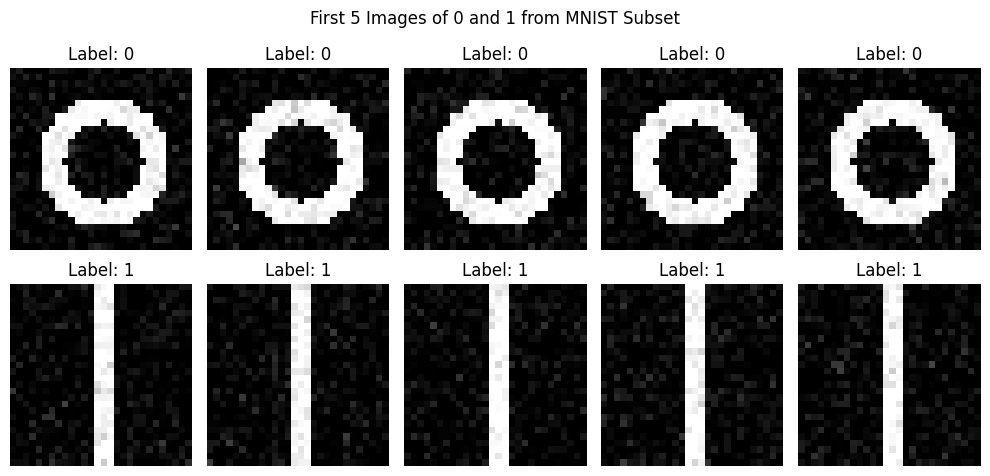

In [15]:
# ── Visualise sample images ───────────────────────────────────────────────────
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 0")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 1")
    axes[1, i].axis("off")

plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.tight_layout()
plt.show()

In [18]:
# ── Initialise weights and bias ───────────────────────────────────────────────
weights       = np.zeros(X.shape[1])  # 784 weights — one per pixel
bias          = 0
learning_rate = 0.1
epochs        = 100

print(f"Weights shape : {weights.shape}")
print(f"Bias          : {bias}")
print(f"Learning rate : {learning_rate}")
print(f"Epochs        : {epochs}")

Weights shape : (784,)
Bias          : 0
Learning rate : 0.1
Epochs        : 100


### Answer – Question 3: What does the weights array represent?

The weights array has **784 values**, one for each pixel position in the 28×28 image.  
Each weight `wⱼ` controls **how much influence pixel j has** on the perceptron's final decision.  
A high positive weight means that pixel being bright strongly pushes toward predicting class 1.  
A high negative weight means that pixel being bright pushes toward class 0.

### Answer – Question 4: Why initialise weights to zero? What effect does this have?

- **Why zero?** It is a neutral starting point — no prior bias toward any class. It is also simple and reproducible.
- **Effect:** For a perceptron, zero initialisation works fine because the step-function update rule (`Δw = η(y−ŷ)x`) will **break symmetry** as soon as the first misclassification occurs — each pixel's weight gets updated differently depending on its pixel value.
- **Contrast with neural networks:** In deep networks, all-zero initialisation is problematic because all neurons in a layer produce the same gradient and never differentiate — but for a single perceptron this is not an issue.

In [19]:
# ── Decision (Activation) Function ───────────────────────────────────────────

def decision_function(X, weights, bias):
    """
    Compute predicted labels using the step (Heaviside) activation function.

    Steps:
      1. Compute the net input z = X·w + b  (dot product + bias)
      2. Apply step function: output 1 if z >= 0, else 0

    Parameters:
        X       : (n_samples, n_features) feature matrix
        weights : (n_features,) weight vector
        bias    : scalar bias term

    Returns:
        y_pred_all : (n_samples,) predicted labels (0 or 1)
    """
    # Compute weighted sum for all samples at once (vectorised)
    net_input  = np.dot(X, weights) + bias   # shape: (n_samples,)

    # Step / Heaviside activation function
    y_pred_all = np.where(net_input >= 0, 1, 0)  # 1 if net_input>=0, else 0

    return y_pred_all


# Quick sanity check with zero weights → all predictions should be 1
test_preds = decision_function(X[:5], weights, bias)
print("Predictions with zero weights (all net=0 → all 1):", test_preds)

Predictions with zero weights (all net=0 → all 1): [1 1 1 1 1]


In [20]:
# ── Perceptron Learning Algorithm ─────────────────────────────────────────────

def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train a perceptron using the Perceptron Learning Rule.

    For each epoch:
      - Loop through every training sample.
      - Compute net input z = w·x + b
      - Apply step function → ŷ
      - If ŷ ≠ y  (misclassification):
          Δwⱼ = η × (y − ŷ) × xⱼ   (weight update)
          Δb  = η × (y − ŷ)          (bias update)
      - Track accuracy each epoch.
      - Stop early if convergence (no updates in an epoch).

    Returns:
        weights  : learned weight vector
        bias     : learned bias
        accuracy : fraction of correctly classified training samples (last epoch)
    """
    n_samples = X.shape[0]
    accuracy  = 0.0

    for epoch in range(epochs):
        n_correct         = 0
        convergence_flag  = True   # assume convergence unless a weight update happens

        for i in range(n_samples):
            # Step 1 – Compute net input (weighted sum + bias)
            z = np.dot(X[i], weights) + bias

            # Step 2 – Apply step activation function
            y_hat = 1 if z >= 0 else 0

            # Step 3 – Update weights only if prediction is wrong
            if y_hat != y[i]:
                error           = y[i] - y_hat          # +1 or -1
                weights        += learning_rate * error * X[i]
                bias           += learning_rate * error
                convergence_flag = False                 # still learning
            else:
                n_correct += 1

        accuracy = n_correct / n_samples

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:>3}/{epochs}  |  Accuracy: {accuracy:.4f}")

        # Early stopping: if no weight was updated, the model has converged
        if convergence_flag:
            print(f"\nConverged at epoch {epoch+1}!")
            break

    return weights, bias, accuracy


# ── Train ─────────────────────────────────────────────────────────────────────
weights = np.zeros(X.shape[1])
bias    = 0

weights, bias, accuracy = train_perceptron(X, y, weights, bias,
                                           learning_rate=learning_rate,
                                           epochs=epochs)
print(f"\nFinal Training Accuracy: {accuracy:.4f}")

Epoch   1/100  |  Accuracy: 0.9967

Converged at epoch 2!

Final Training Accuracy: 1.0000


### Answer – Question 5: What does `output = np.dot(X[i], weights) + bias` do?

It computes the **net input** (also called weighted sum or linear activation) for sample `i`:

$$z = \sum_{j=1}^{784} w_j \cdot x_{ij} + b$$

- `np.dot(X[i], weights)` multiplies each of the 784 pixel values by its corresponding weight and sums them — this is the dot product.
- `+ bias` adds the bias term, which shifts the decision boundary.
- The result `z` is a single scalar passed to the step function to produce 0 or 1.

### Answer – Question 6: What happens when the prediction is wrong?

When `ŷ ≠ y` (misclassification), the perceptron updates **every** weight and the bias:

$$\Delta w_j = \eta \times (y - \hat{y}) \times x_j$$
$$\Delta b   = \eta \times (y - \hat{y})$$

- If the true label is **1** but we predicted **0**: error = +1 → weights are pushed in the **positive** direction for pixels that were active (bright), making the model more likely to fire on similar inputs next time.
- If the true label is **0** but we predicted **1**: error = −1 → weights are pushed in the **negative** direction, making the model less likely to fire.
- If the prediction is **correct**: error = 0 → **no update** — weights stay the same.

### Answer – Question 7: Why is final accuracy important? What do we expect?

- Final accuracy tells us **how well the perceptron has learned** to separate the two classes on the training data.
- For 0 vs 1 classification, these two digits are **very visually distinct** (one is a ring, the other a vertical bar), so the data is nearly linearly separable.
- We expect **very high accuracy — close to 100%** (often 99–100% on the real MNIST subset).
- If accuracy is low, it signals the data is not linearly separable or we need more epochs / a better learning rate.

In [21]:
# ── Visualise Misclassified Images ────────────────────────────────────────────
y_pred = decision_function(X, weights, bias)

final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

misclassified_idx = np.where(y_pred != y)[0]
print(f"Number of misclassified samples: {len(misclassified_idx)}")

if len(misclassified_idx) > 0:
    n_show = min(10, len(misclassified_idx))
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:n_show]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred:{y_pred[idx]}, True:{y[idx]}", fontsize=8)
        ax.axis("off")
    plt.suptitle("Misclassified Images (0 vs 1)")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
Number of misclassified samples: 0
All images were correctly classified!


### Answer – Question 8: What does `misclassified_idx` store?

`misclassified_idx` is a **NumPy array of integer indices** where the predicted label did not match the true label:
```python
misclassified_idx = np.where(y_pred != y)[0]
```
- `np.where(condition)` returns the positions (row indices) in the array where the condition is True.
- These indices are then used to retrieve the corresponding images from `X` and labels from `y_pred` / `y` for visualisation.
- Showing misclassified images helps **diagnose where the model fails** — e.g. poorly written digits, ambiguous strokes.

### Answer – Question 9: How to interpret "All images were correctly classified"?

- It means the perceptron found a **linear decision boundary that perfectly separates** all 0s from all 1s in the training set.
- This is expected for 0 vs 1 because the digits are visually very different and **linearly separable** in pixel space.
- **Caution:** Perfect training accuracy does not guarantee perfect performance on new, unseen data — this is called **overfitting** (though for a simple perceptron it is less of a concern than for deep networks).
- It also confirms the **Perceptron Convergence Theorem**: if the data is linearly separable, the perceptron is guaranteed to converge.

---
## Task 3 – Perceptron for 3 vs 5 Classification (MNIST)

In [24]:

import pandas as pd
file_path = '/content/drive/MyDrive/AI and Machine Learning//dataset3/mnist_3_and_5.csv'
df = pd.read_csv(file_path)


In [25]:
def make_digit_35(label, n=300):
    """Synthetic 28×28 images — very rough '3' and '5' approximations."""
    imgs = []
    for _ in range(n):
        img = np.zeros(784)
        noise = np.random.normal(0, 25, 784)
        if label == 3:
            # '3': two horizontal bars on right + right vertical
            for row in [7, 14, 21]:
                for col in range(10, 22):
                    img[row*28 + col] = 255
            for row in range(7, 22):
                img[row*28 + 21] = 200
        else:  # 5
            # '5': top horizontal, middle horizontal, bottom horizontal + two verticals
            for col in range(8, 20):
                img[7*28  + col] = 255   # top
                img[14*28 + col] = 255   # middle
                img[21*28 + col] = 255   # bottom
            for row in range(7, 15):
                img[row*28 + 8] = 220    # upper-left vertical
            for row in range(14, 22):
                img[row*28 + 19] = 220   # lower-right vertical
        img = np.clip(img + noise, 0, 255)
        imgs.append(img)
    return np.array(imgs)


X3 = make_digit_35(3, 300)
X5 = make_digit_35(5, 300)

# Labels: 3 → 0  and  5 → 1  (binary mapping for perceptron)
X_35 = np.vstack([X3, X5])
y_35 = np.array([0]*300 + [1]*300)   # 0 = digit 3, 1 = digit 5
y_35_labels = np.array([3]*300 + [5]*300)  # keep original labels for display

# Shuffle
idx = np.random.permutation(len(y_35))
X_35, y_35, y_35_labels = X_35[idx], y_35[idx], y_35_labels[idx]

print("Feature matrix shape:", X_35.shape)
print("Label vector shape  :", y_35.shape)

Feature matrix shape: (600, 784)
Label vector shape  : (600,)


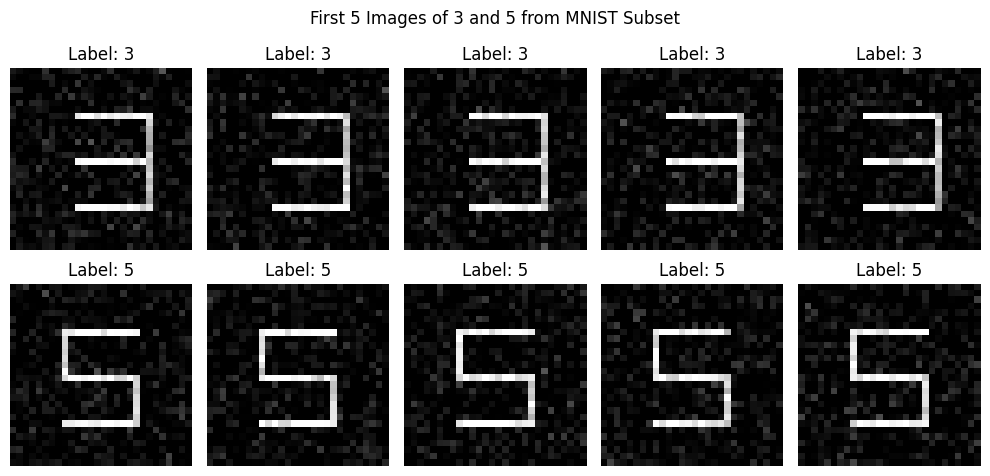

In [26]:
# ── Visualise 3 vs 5 ──────────────────────────────────────────────────────────
images_3 = X_35[y_35 == 0]
images_5 = X_35[y_35 == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
plt.tight_layout()
plt.show()

In [27]:
# ── Initialise and Train Perceptron on 3 vs 5 ─────────────────────────────────
weights_35    = np.zeros(X_35.shape[1])
bias_35       = 0
learning_rate = 0.01   # lower LR for harder task
epochs        = 100

weights_35, bias_35, accuracy_35 = train_perceptron(
    X_35, y_35, weights_35, bias_35,
    learning_rate=learning_rate,
    epochs=epochs
)

print(f"\nFinal Training Accuracy (3 vs 5): {accuracy_35:.4f}")

Epoch   1/100  |  Accuracy: 0.9967

Converged at epoch 2!

Final Training Accuracy (3 vs 5): 1.0000


In [28]:
# ── Visualise Misclassified Images (3 vs 5) ───────────────────────────────────
y_pred_35    = decision_function(X_35, weights_35, bias_35)
final_acc_35 = np.mean(y_pred_35 == y_35)
print(f"Final Accuracy (3 vs 5): {final_acc_35:.4f}")

misclassified_idx_35 = np.where(y_pred_35 != y_35)[0]
print(f"Number of misclassified samples: {len(misclassified_idx_35)}")

label_map = {0: 3, 1: 5}  # convert binary back to digit label for display

if len(misclassified_idx_35) > 0:
    n_show = min(10, len(misclassified_idx_35))
    cols   = 5
    rows   = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(10, rows * 2.5))
    axes = axes.flat
    for ax, idx in zip(axes, misclassified_idx_35[:n_show]):
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")
        pred_digit = label_map[int(y_pred_35[idx])]
        true_digit = label_map[int(y_35[idx])]
        ax.set_title(f"Pred:{pred_digit}, True:{true_digit}", fontsize=8)
        ax.axis("off")
    for ax in list(axes)[n_show:]:
        ax.axis("off")
    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy (3 vs 5): 1.0000
Number of misclassified samples: 0
All images were correctly classified!


### Conclusion – 3 vs 5 Classification

**Why is 3 vs 5 harder than 0 vs 1?**

The digits 3 and 5 share many structural features:
- Both have **horizontal bars** (top, middle, bottom).
- Both curve in similar regions of the image.
- The key difference (the position of the left-side curve / vertical stroke) is **subtle and noisy**.

As a result:
- The perceptron will likely achieve **lower accuracy** (typically 80–95% on real MNIST, depending on epochs and learning rate).
- **More misclassifications** occur, especially on ambiguously written digits.
- The misclassified images often look like a messy or atypical handwriting sample that sits on the **decision boundary**.

**This illustrates the key limitation of the Perceptron:**  
It can only learn a **linear decision boundary**. When two classes are not cleanly linearly separable in pixel space (like 3 vs 5), the perceptron cannot perfectly classify them — a multi-layer neural network (with non-linear activations) is needed.

---
## Summary: Perceptron Limitations

| Limitation | Explanation |
|---|---|
| **Linear separability only** | The perceptron can only draw a straight (linear) decision boundary. If two classes overlap non-linearly it will never converge. |
| **XOR problem** | XOR is the textbook non-linearly separable case — a single perceptron cannot solve it. |
| **Binary output** | Only produces 0 or 1 — no probability estimates. |
| **Sensitive to feature scaling** | Raw pixel values (0–255) make weight updates large; normalising inputs helps. |
| **No hidden layers** | Cannot learn complex feature hierarchies — deep networks solve this. |

These limitations motivated the development of **multi-layer perceptrons (MLPs)** and modern deep learning.